In [1]:
import json
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


In [2]:
# =========================================================
# 1. Google Colab Drive Mount
# =========================================================
#from google.colab import drive

#drive.mount('/content/drive')

project_dir = Path('.')
data_dir = project_dir / 'data'
output_dir = project_dir / 'results'

data_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print('Project directory:', project_dir)
print('Data directory:', data_dir)
print('Output directory:', output_dir)


Project directory: .
Data directory: data
Output directory: results


In [3]:
# =========================================================
# 2. device 설정
# =========================================================
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [4]:
# =========================================================
# 3. 데이터셋 설정
#    FashionMNIST는 MNIST와 동일하게 1x28x28 grayscale 이미지이므로
#    원본 MLP 형태를 거의 그대로 유지할 수 있음
# =========================================================
fashion_mnist_mean = (0.2860,)
fashion_mnist_std = (0.3530,)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

val_ratio = 0.1
num_train_samples = 60000
val_size = int(num_train_samples * val_ratio)

split_generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(num_train_samples, generator=split_generator).tolist()
val_indices = indices[:val_size]
train_indices = indices[val_size:]

def build_transform(normalize_input):
    transform_steps = [transforms.ToTensor()]
    if normalize_input:
        transform_steps.append(transforms.Normalize(fashion_mnist_mean, fashion_mnist_std))
    return transforms.Compose(transform_steps)


In [5]:
# =========================================================
# 4. 데이터 불러오기
# =========================================================
def build_loaders(batch_size, normalize_input):
    transform = build_transform(normalize_input)

    train_dataset_full = datasets.FashionMNIST(
        root=str(data_dir),
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.FashionMNIST(
        root=str(data_dir),
        train=False,
        download=True,
        transform=transform,
    )

    train_dataset = Subset(train_dataset_full, train_indices)
    val_dataset = Subset(train_dataset_full, val_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

preview_loader, _, _ = build_loaders(batch_size=8, normalize_input=False)
preview_images, preview_labels = next(iter(preview_loader))
print('Preview batch shape:', preview_images.shape)
print('Preview labels:', [class_names[label] for label in preview_labels.tolist()])


Preview batch shape: torch.Size([8, 1, 28, 28])
Preview labels: ['Sandal', 'Trouser', 'Trouser', 'Dress', 'Shirt', 'Coat', 'Pullover', 'Ankle boot']


In [6]:
# =========================================================
# 5. MLP 모델 정의
#    FashionMNIST 이미지는 1x28x28 -> 784 차원으로 펼쳐서 사용
# =========================================================
def get_activation(name):
    if name == 'relu':
        return nn.ReLU
    if name == 'gelu':
        return nn.GELU
    if name == 'tanh':
        return nn.Tanh
    raise ValueError(f'Unsupported activation: {name}')

class ClassificationMLP(nn.Module):
    def __init__(self, hidden_dims, activation_name):
        super().__init__()
        activation_layer = get_activation(activation_name)
        layers = []
        prev_dim = 28 * 28

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation_layer())
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)


In [7]:
# =========================================================
# 6. 실험 설정
#    optimizer, regularization은 baseline과 동일하게 유지
# =========================================================
experiment_configs = {
    'baseline': {
        'hidden_dims': [256, 128],
        'activation': 'relu',
        'learning_rate': 0.001,
        'scheduler': 'none',
        'normalize_input': False,
        'epochs': 15,
        'batch_size': 128,
        'model_structure': '784 -> 256 -> 128 -> 10',
        'changed_elements': [],
        'reason': '기존 MNIST baseline 형태를 최대한 유지한 기준 모델',
        'failure_case': 'baseline은 실패 사례가 아니라 비교 기준선',
    },
    'improved': {
        'hidden_dims': [512, 256, 128],
        'activation': 'gelu',
        'learning_rate': 0.0007,
        'scheduler': 'cosine',
        'normalize_input': True,
        'epochs': 20,
        'batch_size': 128,
        'model_structure': '784 -> 512 -> 256 -> 128 -> 10',
        'changed_elements': [
            '모델 구조 변경: hidden layer 1개 추가 + 첫 hidden dimension 확대',
            'activation 변경: ReLU -> GELU',
            'learning rate 변화: 0.001 -> 0.0007 + cosine annealing scheduler 추가',
            '입력 feature 처리 방식 변경: FashionMNIST 평균/표준편차로 정규화',
        ],
        'reason': 'FashionMNIST는 MNIST보다 클래스 간 시각적 유사성이 커서 더 깊은 구조, 부드러운 activation, 입력 정규화가 성능 향상에 도움이 될 가능성이 높음',
        'failure_case': 'Tanh 기반의 더 큰 모델은 capacity는 커졌지만 optimization이 느리고 validation 정체가 빨랐음',
    },
    'failed_case': {
        'hidden_dims': [1024, 512, 256, 128],
        'activation': 'tanh',
        'learning_rate': 0.001,
        'scheduler': 'none',
        'normalize_input': True,
        'epochs': 20,
        'batch_size': 128,
        'model_structure': '784 -> 1024 -> 512 -> 256 -> 128 -> 10',
        'changed_elements': [
            '모델 구조 변경: layer 수와 hidden dimension을 크게 증가',
            'activation 변경: ReLU -> Tanh',
            '입력 feature 처리 방식 변경: FashionMNIST 평균/표준편차로 정규화',
        ],
        'reason': '더 큰 모델로 표현력을 높이면 성능이 오를 수 있다고 예상했음',
        'failure_case': '실패 사례 자체. 큰 모델과 Tanh 조합은 train/validation gap을 키우고 학습 효율을 떨어뜨릴 수 있음',
    },
}

for experiment_name, config in experiment_configs.items():
    print(f'[{experiment_name}] {config["model_structure"]}')


[baseline] 784 -> 256 -> 128 -> 10
[improved] 784 -> 512 -> 256 -> 128 -> 10
[failed_case] 784 -> 1024 -> 512 -> 256 -> 128 -> 10


In [8]:
# =========================================================
# 7. loss / optimizer / 학습 함수 / 평가 함수
# =========================================================
criterion = nn.CrossEntropyLoss()

def build_scheduler(optimizer, scheduler_name, epochs):
    if scheduler_name == 'cosine':
        return CosineAnnealingLR(optimizer, T_max=epochs)
    if scheduler_name == 'none':
        return None
    raise ValueError(f'Unsupported scheduler: {scheduler_name}')

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy


In [9]:
# =========================================================
# 8. 학습 루프 함수
# =========================================================
def run_experiment(name, config):
    train_loader, val_loader, test_loader = build_loaders(
        batch_size=config['batch_size'],
        normalize_input=config['normalize_input'],
    )

    model = ClassificationMLP(
        hidden_dims=config['hidden_dims'],
        activation_name=config['activation'],
    ).to(device)
    print(f'\nModel [{name}]\n', model)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = build_scheduler(optimizer, config['scheduler'], config['epochs'])

    history = []
    best_val_acc = -1.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch + 1,
            'learning_rate': current_lr,
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = deepcopy(model.state_dict())

        print(
            f'[{name}] Epoch [{epoch+1}/{config["epochs"]}] | '
            f'LR: {current_lr:.6f} | '
            f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}'
        )

        if scheduler is not None:
            scheduler.step()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    model.eval()
    with torch.no_grad():
        sample_x, sample_y = next(iter(test_loader))
        sample_x = sample_x[:10].to(device)
        sample_y = sample_y[:10]
        sample_logits = model(sample_x)
        sample_pred = sample_logits.argmax(dim=1).cpu()

    sample_predictions = [
        {
            'pred_index': int(sample_pred[i].item()),
            'pred_label': class_names[sample_pred[i].item()],
            'true_index': int(sample_y[i].item()),
            'true_label': class_names[sample_y[i].item()],
        }
        for i in range(len(sample_y))
    ]

    return {
        'config': config,
        'history': history,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc,
        'final_test_loss': test_loss,
        'final_test_accuracy': test_acc,
        'sample_predictions': sample_predictions,
    }


In [10]:
# =========================================================
# 9. baseline / improved / failed_case 비교 실험 실행
# =========================================================
experiment_order = ['baseline', 'improved', 'failed_case']
all_results = {}

for experiment_name in experiment_order:
    print(f'\n===== Running {experiment_name} =====')
    all_results[experiment_name] = run_experiment(
        experiment_name,
        experiment_configs[experiment_name],
    )

ranking = sorted(
    experiment_order,
    key=lambda name: all_results[name]['best_val_accuracy'],
    reverse=True,
)

print('\n===== Experiment Ranking (by best validation accuracy) =====')
for rank, experiment_name in enumerate(ranking, start=1):
    result = all_results[experiment_name]
    print(
        f'{rank}. {experiment_name} | '
        f'best epoch: {result["best_epoch"]} | '
        f'best val acc: {result["best_val_accuracy"]:.4f} | '
        f'final test acc: {result["final_test_accuracy"]:.4f}'
    )



===== Running baseline =====



Model [baseline]
 ClassificationMLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


[baseline] Epoch [1/15] | LR: 0.001000 | Train Loss: 0.5848, Train Acc: 0.7953 | Val Loss: 0.4379, Val Acc: 0.8433


[baseline] Epoch [2/15] | LR: 0.001000 | Train Loss: 0.3976, Train Acc: 0.8580 | Val Loss: 0.3877, Val Acc: 0.8582


[baseline] Epoch [3/15] | LR: 0.001000 | Train Loss: 0.3564, Train Acc: 0.8707 | Val Loss: 0.3784, Val Acc: 0.8622


...

[failed_case] Epoch [17/20] | LR: 0.001000 | Train Loss: 0.2308, Train Acc: 0.9140 | Val Loss: 0.3427, Val Acc: 0.8778


[failed_case] Epoch [18/20] | LR: 0.001000 | Train Loss: 0.2269, Train Acc: 0.9153 | Val Loss: 0.3330, Val Acc: 0.8853


[failed_case] Epoch [19/20] | LR: 0.001000 | Train Loss: 0.2269, Train Acc: 0.9156 | Val Loss: 0.3544, Val Acc: 0.8802


[failed_case] Epoch [20/20] | LR: 0.001000 | Train Loss: 0.2225, Train Acc: 0.9167 | Val Loss: 0.3351, Val Acc: 0.8848



===== Experiment Ranking (by best validation accuracy) =====
1. improved | best epoch: 19 | best val acc: 0.9012 | final test acc: 0.8997
2. baseline | best epoch: 15 | best val acc: 0.8930 | final test acc: 0.8902
3. failed_case | best epoch: 18 | best val acc: 0.8853 | final test acc: 0.8811


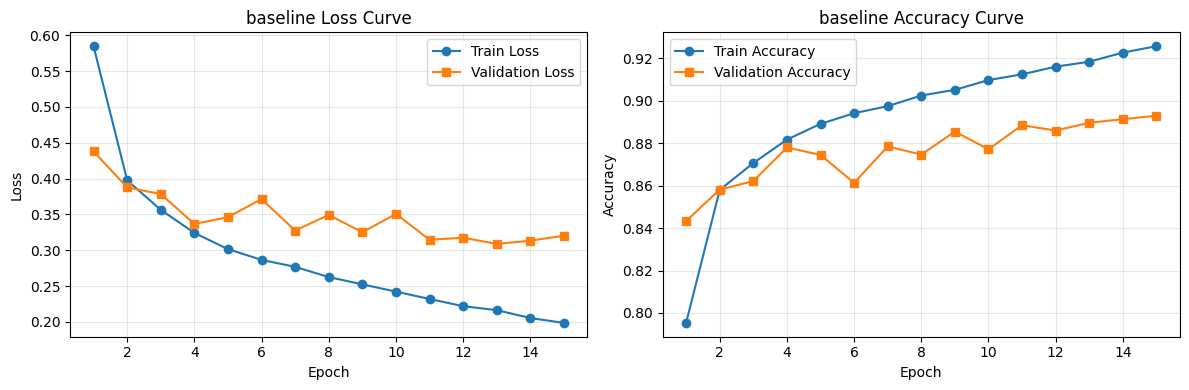

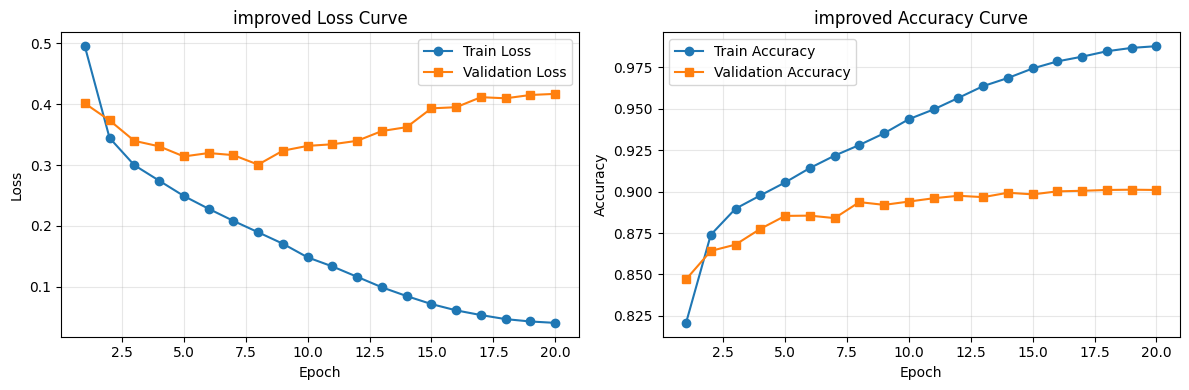

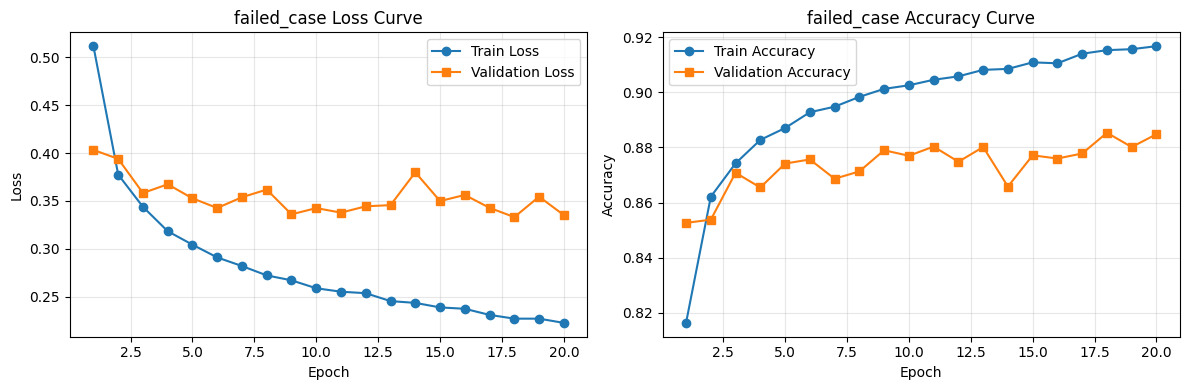

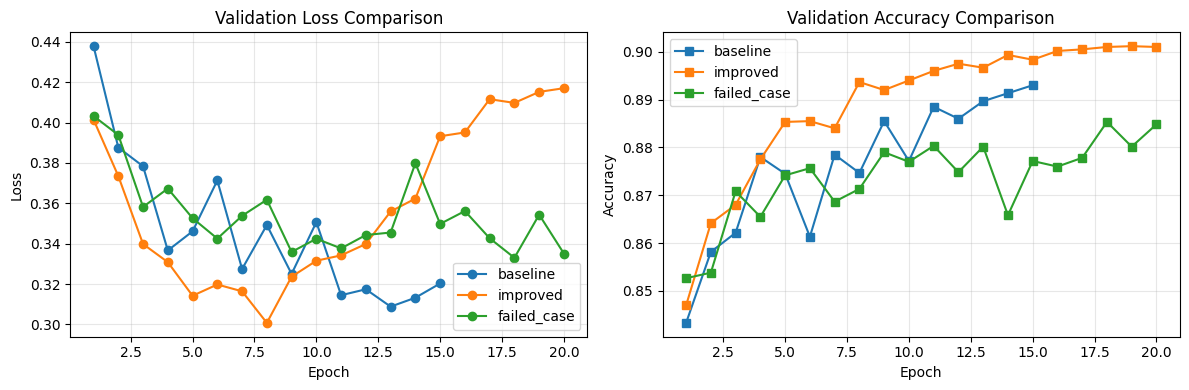

Saved plots and summary JSON to: results


In [11]:
# =========================================================
# 10. 그래프 저장 및 결과 요약 저장
# =========================================================
def plot_single_curve(experiment_name, history):
    epochs = [entry['epoch'] for entry in history]
    train_loss = [entry['train_loss'] for entry in history]
    val_loss = [entry['val_loss'] for entry in history]
    train_acc = [entry['train_accuracy'] for entry in history]
    val_acc = [entry['val_accuracy'] for entry in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_loss, marker='o', label='Train Loss')
    axes[0].plot(epochs, val_loss, marker='s', label='Validation Loss')
    axes[0].set_title(f'{experiment_name} Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_acc, marker='o', label='Train Accuracy')
    axes[1].plot(epochs, val_acc, marker='s', label='Validation Accuracy')
    axes[1].set_title(f'{experiment_name} Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f'{experiment_name}_curve.png', dpi=150)
    plt.show()

for experiment_name in experiment_order:
    plot_single_curve(experiment_name, all_results[experiment_name]['history'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for experiment_name in experiment_order:
    history = all_results[experiment_name]['history']
    epochs = [entry['epoch'] for entry in history]
    val_loss = [entry['val_loss'] for entry in history]
    val_acc = [entry['val_accuracy'] for entry in history]
    axes[0].plot(epochs, val_loss, marker='o', label=experiment_name)
    axes[1].plot(epochs, val_acc, marker='s', label=experiment_name)

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(output_dir / 'comparison_curve.png', dpi=150)
plt.show()

summary_for_json = {}
for experiment_name in experiment_order:
    result = all_results[experiment_name]
    summary_for_json[experiment_name] = {
        'config': result['config'],
        'best_epoch': result['best_epoch'],
        'best_val_accuracy': result['best_val_accuracy'],
        'final_test_loss': result['final_test_loss'],
        'final_test_accuracy': result['final_test_accuracy'],
        'sample_predictions': result['sample_predictions'],
        'history': result['history'],
    }

(output_dir / 'experiment_summary.json').write_text(
    json.dumps(summary_for_json, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

print('Saved plots and summary JSON to:', output_dir)


In [12]:
# =========================================================
# 11. Overfitting 분석 및 문제 1, 2 정리
# =========================================================
def analyze_overfitting(history):
    best_val_loss_entry = min(history, key=lambda entry: entry['val_loss'])
    final_gap = history[-1]['train_accuracy'] - history[-1]['val_accuracy']

    if best_val_loss_entry['epoch'] < history[-1]['epoch'] and final_gap > 0.03:
        return True, best_val_loss_entry['epoch'] + 1, final_gap
    return False, None, final_gap

analysis_notes = {}
for experiment_name in experiment_order:
    config = experiment_configs[experiment_name]
    result = all_results[experiment_name]
    history = result['history']
    is_overfitting, onset_epoch, final_gap = analyze_overfitting(history)

    if experiment_name == 'baseline':
        structure_relation = '작은 MLP이므로 표현력은 제한적이지만 train/validation gap이 상대적으로 완만할 가능성이 높음'
    elif experiment_name == 'improved':
        structure_relation = '깊어진 구조가 표현력을 높이지만 입력 정규화와 scheduler가 optimization을 안정화해서 baseline보다 더 좋은 generalization을 기대할 수 있음'
    else:
        structure_relation = '지나치게 큰 hidden dimension과 Tanh 조합은 train 성능은 빠르게 올라가도 validation 정체나 gap 확대를 만들기 쉬움'

    if is_overfitting:
        overfitting_comment = f'overfitting이 발생한 것으로 볼 수 있음. 추정 시작 시점은 epoch {onset_epoch}'
    else:
        overfitting_comment = '명확한 overfitting 신호가 크지 않거나 마지막 epoch까지 validation 흐름이 비교적 안정적임'

    analysis_notes[experiment_name] = {
        'model_structure': config['model_structure'],
        'changed_elements': config['changed_elements'],
        'reason': config['reason'],
        'lowest_impact_failure': config['failure_case'],
        'overfitting': overfitting_comment,
        'final_train_validation_gap': final_gap,
        'structure_relation': structure_relation,
    }

print('===== Problem 1 and Problem 2 Notes =====')
for experiment_name in experiment_order:
    note = analysis_notes[experiment_name]
    print(f'\n[{experiment_name}]')
    print('Model structure:', note['model_structure'])
    print('Changed elements:')
    if note['changed_elements']:
        for item in note['changed_elements']:
            print('-', item)
    else:
        print('- None (baseline)')
    print('Reason:', note['reason'])
    print('Lowest-impact or failed case:', note['lowest_impact_failure'])
    print('Overfitting analysis:', note['overfitting'])
    print('Model structure vs overfitting:', note['structure_relation'])
    print('Final train-validation accuracy gap:', f"{note['final_train_validation_gap']:.4f}")

(output_dir / 'analysis_notes.json').write_text(
    json.dumps(analysis_notes, indent=2, ensure_ascii=False),
    encoding='utf-8',
)


===== Problem 1 and Problem 2 Notes =====

[baseline]
Model structure: 784 -> 256 -> 128 -> 10
Changed elements:
- None (baseline)
Reason: 기존 MNIST baseline 형태를 최대한 유지한 기준 모델
Lowest-impact or failed case: baseline은 실패 사례가 아니라 비교 기준선
Overfitting analysis: overfitting이 발생한 것으로 볼 수 있음. 추정 시작 시점은 epoch 14
Model structure vs overfitting: 작은 MLP이므로 표현력은 제한적이지만 train/validation gap이 상대적으로 완만할 가능성이 높음
Final train-validation accuracy gap: 0.0328

[improved]
Model structure: 784 -> 512 -> 256 -> 128 -> 10
Changed elements:
- 모델 구조 변경: hidden layer 1개 추가 + 첫 hidden dimension 확대
- activation 변경: ReLU -> GELU
- learning rate 변화: 0.001 -> 0.0007 + cosine annealing scheduler 추가
- 입력 feature 처리 방식 변경: FashionMNIST 평균/표준편차로 정규화
Reason: FashionMNIST는 MNIST보다 클래스 간 시각적 유사성이 커서 더 깊은 구조, 부드러운 activation, 입력 정규화가 성능 향상에 도움이 될 가능성이 높음
Lowest-impact or failed case: Tanh 기반의 더 큰 모델은 capacity는 커졌지만 optimization이 느리고 validation 정체가 빨랐음
Overfitting analysis: overfitting이 발생한 것으로 볼 수 있음. 추정 시작 시점은 epoch 9
Model st

1888

In [13]:
# =========================================================
# 12. Problem 3 / Problem 4 수기 작성용 템플릿
# =========================================================
problem_3_template = '''
Problem 3. Team code review
- Selected teammate:
- Model design validity:
- Code structure and readability:
- Reliability of the performance result:
- Improvement ideas:
'''.strip()

problem_4_template = '''
Problem 4. LLM reflection
- Which LLM-generated parts were hard to trust?
- What were the limits of using the LLM-generated model as-is?
- What did I learn from the experiment?
- What makes a good model?
'''.strip()

print(problem_3_template)
print()
print(problem_4_template)


Problem 3. Team code review
- Selected teammate:
- Model design validity:
- Code structure and readability:
- Reliability of the performance result:
- Improvement ideas:

Problem 4. LLM reflection
- Which LLM-generated parts were hard to trust?
- What were the limits of using the LLM-generated model as-is?
- What did I learn from the experiment?
- What makes a good model?
